# Примерный план курса

1. Основные понятия временных рядов. Непараметрическое оценивание тренда и сезонности. Экспоненциальное сглаживание.

2. Стационарность. Модели авторегрессии и скользящего среднего. AR, MA, ARIMA. Методы валидации/проверки качества прогноза

3. Сезонные модели: SARIMA, SARIMAX. Модели распределенного лага ARDL

4. Модели с гетероскедостичностью ARCH, GARCH

5. Векторные модели VAR, VARMA, VECM. SVAR, IRF

6. Кластеризация временных рядов. Методы заполнения пропусков. Поиск аномалий

7. Простейшие нейросетевые подходы. MLP + RF. Feature Engineering

8. Prophet, GRU, LSTM

9. Foundation Models и Zero-Shot. TimesFM (Google), Chronos (Amazon), Moirai.

# Тематика домашних заданий

1. Классические модели для одного временного ряда.

2. Векторные модели.

3. Нейросетевые модели.

# Временные ряды. Основные понятия. Примеры

Будем говорить, что **временной ряд** это последовательность случайных
величин (одномерных или многомерных) $x_t=(x_{t_1},...,x_{t_n})$,
наблюдаемая в моменты времени $t_1,...,t_n$ [Box,Jenkins].

Другими словами временной ряд $x_t$ -это случайный процесс с дискретным
временем.  Если интервалы времени $t_k-t_{k-1}=const$ для всех $k$, то
индекс $t_k$ заменим просто на порядковый номер. 

Итак, случайный процесс $x_t=(x_1,...,x_n)$ с дискретным временем будем называть временным
рядом. В теории обычно предполагается, что временной ряд имеет
бесконечную длину и динамика его рассматривается от $-\infty$ до
$\infty$.

В этом случае это записывают так: ${x_t:t = 0,\pm1,\pm2,....}$

Временные ряды часто изображают графически, по оси абцисс располагают
время, наблюдаемые значения процесса отображают по оси ординат. 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

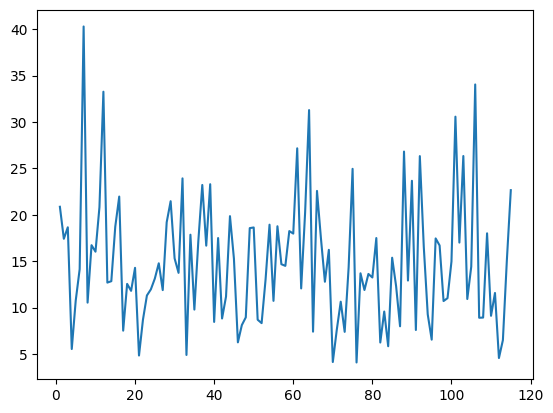

In [2]:
data = pd.read_csv('larain.csv',index_col = 0)
plt.plot(data)
plt.show()

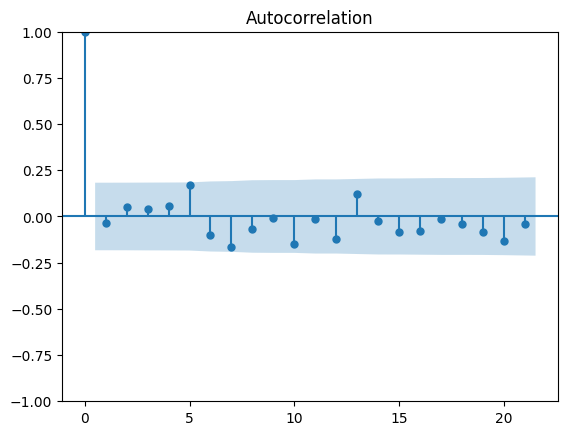

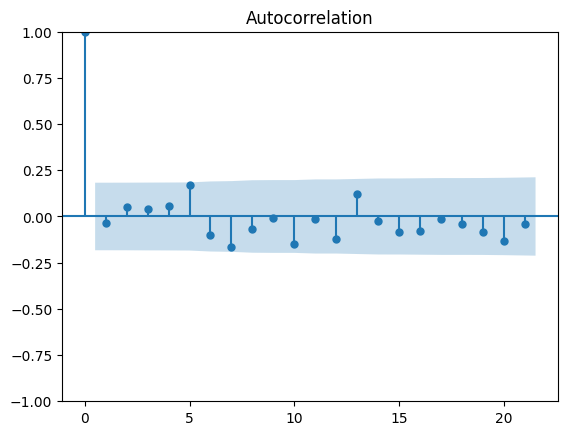

In [3]:
sm.graphics.tsa.plot_acf(data)

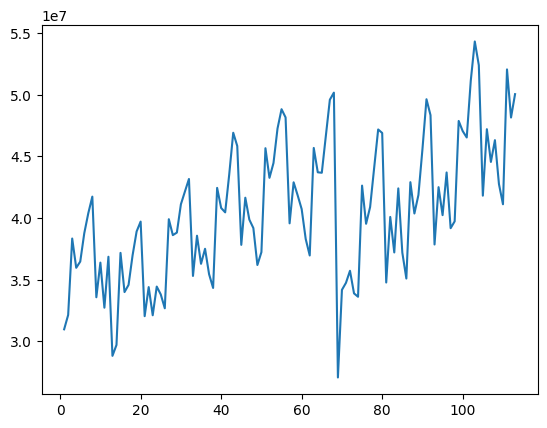

In [4]:
data = pd.read_csv('airmiles.csv', index_col = 0)
data
plt.plot(data)
plt.show()

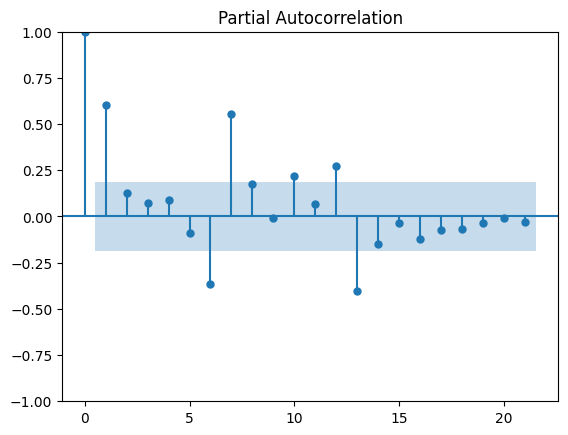

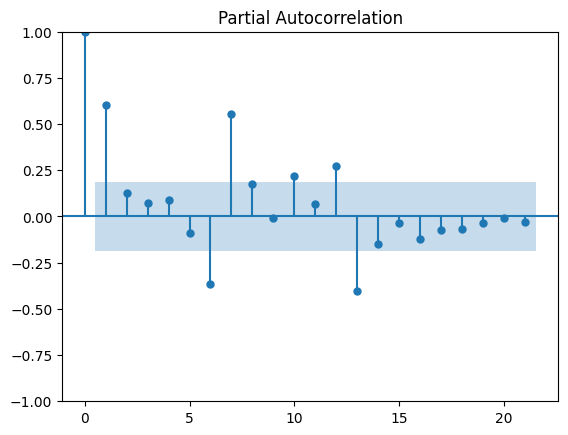

In [6]:
sm.graphics.tsa.plot_pacf(data)

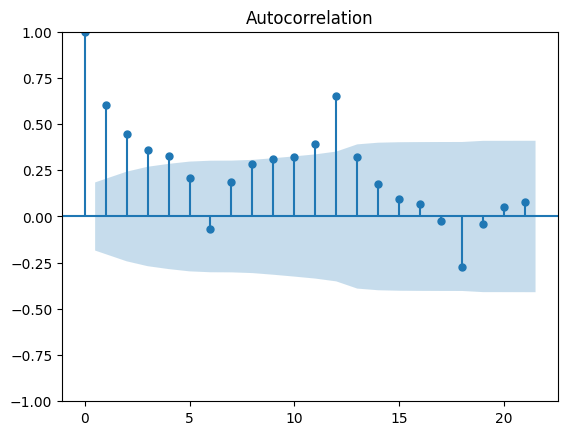

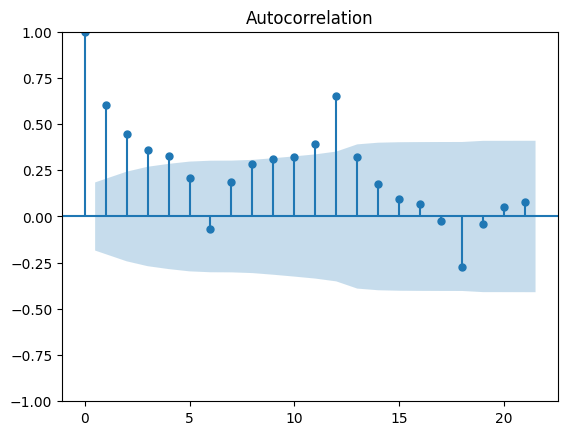

In [5]:
sm.graphics.tsa.plot_acf(data)

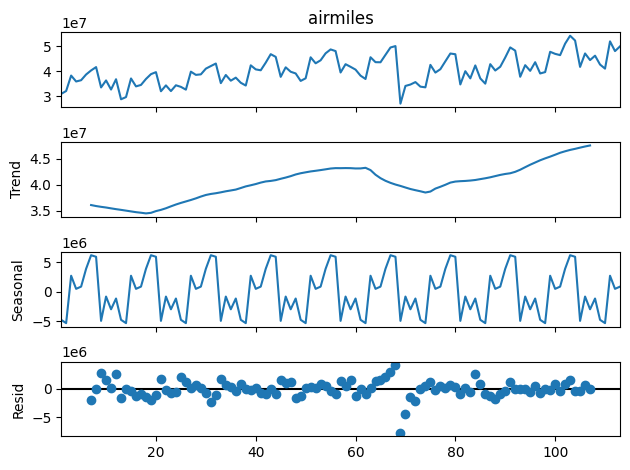

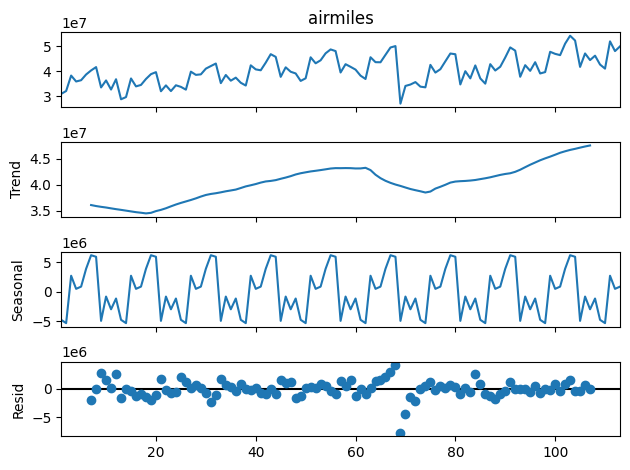

In [13]:
seasonal_decompose(data['airmiles'], period=12).plot()

## Простейшие описательные статистики

Для случайного процесса временого ряда ${x_t:t = 0,\pm1,\pm2,....}$
определим математическое ожидание.

$E[x_t]=\mu_t,t=0,\pm1,\pm2,...$

В общем случае $\mu_t$ различно для каждого $t = 0,\pm1,\pm2,....$

Дисперсия ряда

$D[x_t]=E(x_t-\mu_t)^2= \sigma_t^2 ,t=0,\pm1,\pm2,...$

Очень важную роль будет играть **автоковариационная функция**
$c(x_t,x_s)$ и **автокорреляционная функция** $\gamma(x_t,x_s)$
Определяются они следующим образом соответсвенно

$c(x_t,x_s) =cov(x_t,x_s)=E(x_t-\mu_t)(x_s-\mu_s):s,t=0,\pm1,\pm2,...$

и

$\gamma(x_t,x_s) =\frac{c(x_t,x_s)}{\sqrt{ D[x_t]}\sqrt {D[x_s]}}:s,t=0,\pm1,\pm2,...$

По выборке исторических данных $x_1,...,x_n$ оценка среднего, дисперсии
и автоковариационной функции осуществляется по формулам:

математическое ожидание

$E[x_t]\approx\overline{x}= \frac{1}{n}\sum_{t=1}^nx_t$

дисперсия

$D[x_t]\approx \frac{1}{n-1}\sum_{t=1}^n(x_t- \overline x)^2$

автоковариационная функция стационарного временного ряда зависит от
разности времен $s,t$

$c(s,t)=c(k=|t-s|)\approx \frac{1}{n-k}\sum_{t=1}^{n-k}(x_t- \overline x)(x_{t+k}- \overline x)$

In [ ]:
data = pd.read_csv('larain.csv',index_col = 0)
sm.graphics.tsa.plot_acf(data, lags=50)
plt.show()
sm.graphics.tsa.plot_pacf(data, lags=50)
plt.show()

In [ ]:
data = pd.read_csv('airmiles.csv',index_col = 0)
sm.graphics.tsa.plot_acf(data, lags=50)
plt.show()
sm.graphics.tsa.plot_pacf(data, lags=50)
plt.show()

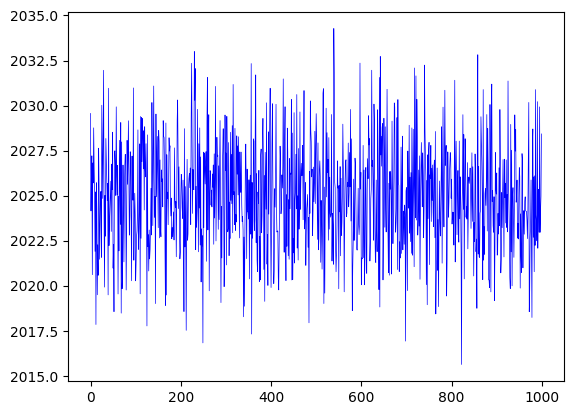

2024.953550040271
3.0019451447715486


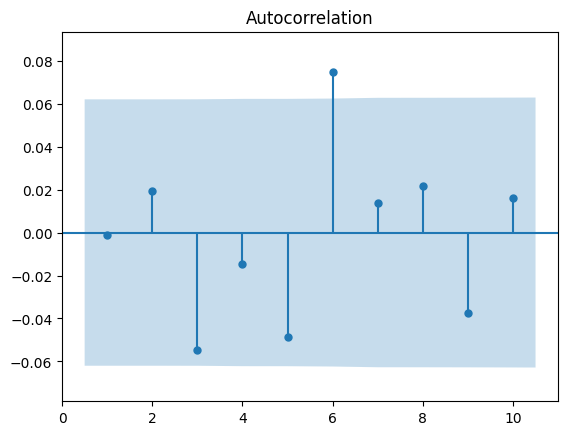

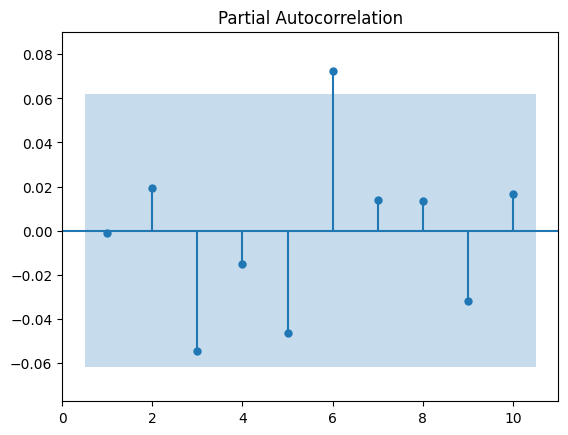

In [14]:
mu = 2025
sigma = 3
data  = np.random.normal(mu, sigma, size = 1000)
plt.plot(data, color = "blue", lw = 0.5)
plt.show()
print(data.mean())
print(data.std())
sm.graphics.tsa.plot_acf(data, lags=10, use_vlines = True, adjusted = True, zero=False, auto_ylims = True)
plt.show()
sm.graphics.tsa.plot_pacf(data, lags=10, use_vlines = True, zero=False, auto_ylims = True)
plt.show()

Пусть $\epsilon_1,...,\epsilon_n$ последовательность независимых
нормально распределенных случйаных величин, или так называемый
нормальный **белый шум** с математическим ожиданием $E[\epsilon_t]=0$ и
дисперсией $D[\epsilon_t]=\sigma_{\epsilon}^2:t=1,..n$

In [ ]:
sigma = 1
white_noise  = np.random.normal(0,sigma, size = 500)
plt.plot(white_noise)
plt.title('White noise')
plt.show()

In [ ]:
sm.graphics.tsa.plot_acf(white_noise)
sm.graphics.tsa.plot_pacf(white_noise)

Построим процесс $x_t$ следующим образом

$x_1=\epsilon_1$

$x_2=x_1+\epsilon_2$

$....$

$x_n=x_{n-1}+\epsilon_n$

Процесс $x_t$ называется **случайным блужданием**.
Нетрудно убедиться, что

$E[x_t]=E[x_{t-1}+\epsilon_t]=E[\epsilon_1+...+\epsilon_t]= 0$,

а

$D[x_t]=D[x_{t-1}+\epsilon_t]=D[\epsilon_1+...+\epsilon_t]=t\sigma_{\epsilon}^2$.

Пусть $1\le t\le s$ .Автокорреляционная функция, так как
$E[\epsilon_t=0]$

$c(x_t,x_s)=E[(\epsilon_1+...\epsilon_t)(\epsilon_1+...\epsilon_s)]=$
$\sum_{i=1}^t\sum_{j=1}^sE[\epsilon_i\epsilon_j]$

Так как $E[\epsilon_i\epsilon_j]=\sigma_\epsilon^2$ при $i=j$ и равно 0
при $i\ne j$ тогда

$c(x_t,x_s)=t\sigma_\epsilon^2$

Более того легко видеть,что при $1\le t\le s$

$c(x_t,x_s)=c(x_s,x_t) = t\sigma_\epsilon^2$

Аналогично легко может быть вычислена и автокорреляционная функция для
процесса $x_t$ случайного блуждания

$\rho(x_t,x_s)=\frac{c(x_t,x_s)}{\sqrt{D[x_t]D[x_s]}}=\sqrt{\frac{t}{s}}$

Случайное блуждание на рисунке выглядит следующим образом

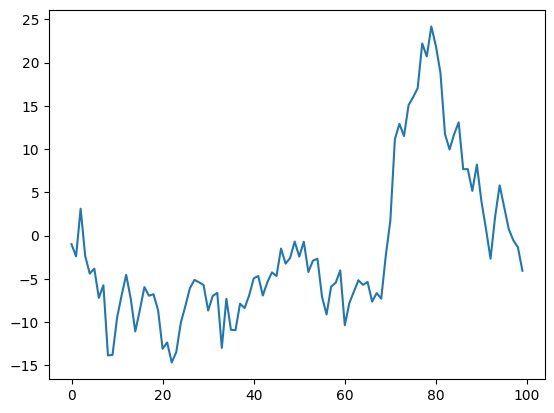

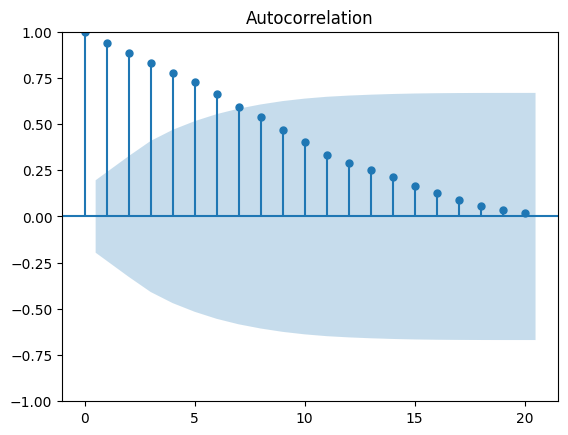

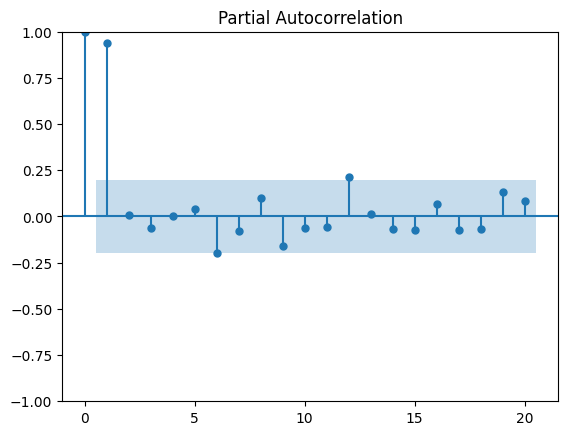

In [15]:
eps  = np.random.normal(0,sigma, size = 100)
random_walk = np.cumsum(eps)
plt.plot(random_walk)
sm.graphics.tsa.plot_acf(random_walk)
sm.graphics.tsa.plot_pacf(random_walk)
plt.show()

## Скользящее среднее

Пусть $\epsilon_1,...,\epsilon_n$ по-прежнему процесс **белого шума**
Построим процессс $x_t:t=1,...,n$ по следующему правилу

$x_t(2)=\frac{\epsilon_t+\epsilon_{t-1}}{2}$

Простейшие вычисления нам дают, что при всех $t=1,...n$
$\mu_t=E[x_t]= E[\frac{\epsilon_t+\epsilon_{t-1}}{2}]= 0$

a

$\sigma_{x,t}^2=D[x_t]= D[\frac{\epsilon_t+\epsilon_{t-1}}{2}]=\frac{D[\epsilon_t]+D[\epsilon_{t-1}]}{4}]=  0.5 \sigma_{\epsilon}^2$

Также нетрудно убедиться,что

$cov(x_t,x_{t-1})= 0.25 \sigma_{\epsilon}^2$

а

$cov(x_t,x_{t-2})= 0$

Объединяя последние 3 выражения, получим, что автоковариационная функция
процесса $x_t$ равна

$с(x_t,x_s)=0.5\sigma_{\epsilon}^2$ при $|t-s|= 0$

$с(x_t,x_s)=0.25\sigma_{\epsilon}^2$ при $|t-s|=1$

$с(x_t,x_s)= 0$ при $|t-s|>1$

для автокорреляционной функции процесса $x_t$

$\rho(x_t,x_s)=1$ при $|t-s|= 0$

$\rho(x_t,x_s)=0.5$ при $|t-s|=1$

$\rho(x_t,x_s)= 0$ при $|t-s|>1$

Аналогично можно ввести скользящее среднее для трех,четырех и любого
произвольного числа $m$ слагаемых

$x_t(m)=\frac{\epsilon_t+\epsilon_{t-1}+...+\epsilon_{t-m}}{m}$

Вычислить математическое ожидание, дисперсию, автоковариационную и
автокорреляционную функции процесса $x_t(m)$ Для любого $m = 2,3,4,...$

$\mu_t=E[x_t]= E[\frac{\sum_{i=0}^{m-1}\epsilon_{t-i}}{m}]= 0$

$\sigma_t^2=D[x_t]= D[\frac{\sum_{i=0}^{m-1}\epsilon_{t-i}}{m}]=\frac{\sum_{i=0}^{m-1}D[\epsilon_{t-i}]}{m^2}=\frac{m\sigma_{\epsilon}^2}{m^2}=\frac{\sigma_{\epsilon}^2}{m}$

Автокоррелляционная функция

$\rho(x_t,x_s)=1$ при $|t-s|= 0$

$\rho(x_t,x_s)\ne0$ при $|t-s|<m$

$\rho(x_t,x_s)= 0$ при $|t-s|\ge m$

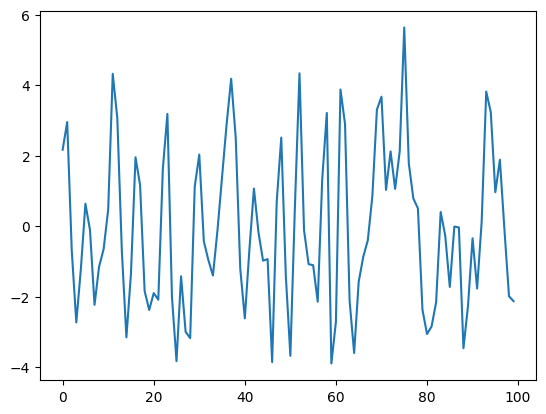

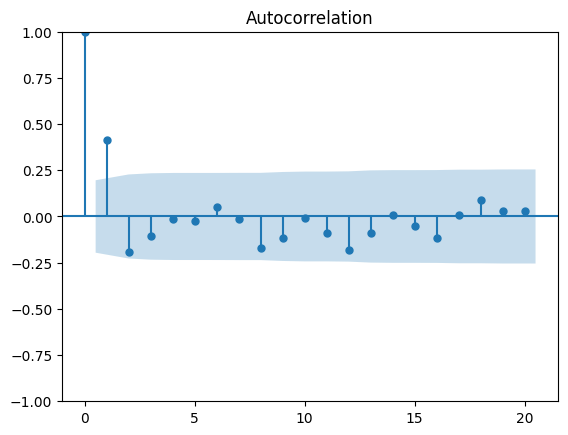

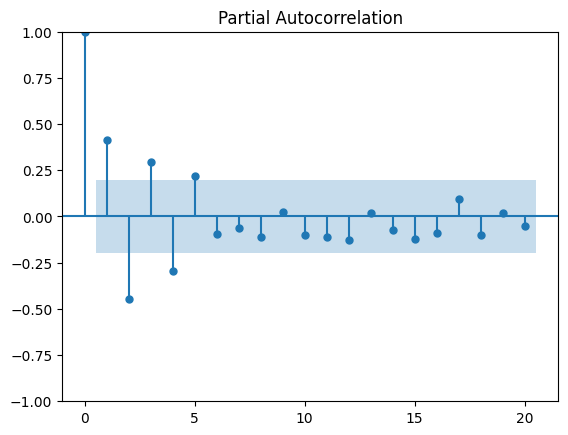

In [16]:
eps  = pd.Series(np.random.normal(0,sigma, size = 100))
x = (eps + eps.shift(1).fillna(0))/2
plt.plot(x)
sm.graphics.tsa.plot_acf(x)
sm.graphics.tsa.plot_pacf(x)
plt.show()

In [ ]:
data = pd.read_csv('Import.csv', header=0)
data 
plt.plot(data['Fact'])
plt.show()

In [ ]:
data

In [ ]:
data = np.array(data['Fact'])

In [ ]:
data

In [ ]:
data = pd.read_csv('airmiles.csv',index_col = 0)
result = seasonal_decompose(data, period = 24)
result.plot()
plt.show()

In [ ]:
result.seasonal.plot()

In [ ]:
plt.plot(data, label = 'data')
plt.plot(result.trend + result.seasonal, label = 'decompose')
plt.legend()
plt.show()

In [ ]:
result = seasonal_decompose(data, model='multiplicative', period=2)
result.plot()
plt.show()

In [ ]:
eps  = np.random.normal(0,sigma, size = 100)
x= [eps[0]]
for i in range(len(eps)):
    x.append(x[len(x)-1] + eps[i])
x = np.array(x)
result = seasonal_decompose(x, model='additive', period=2)
result.plot()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


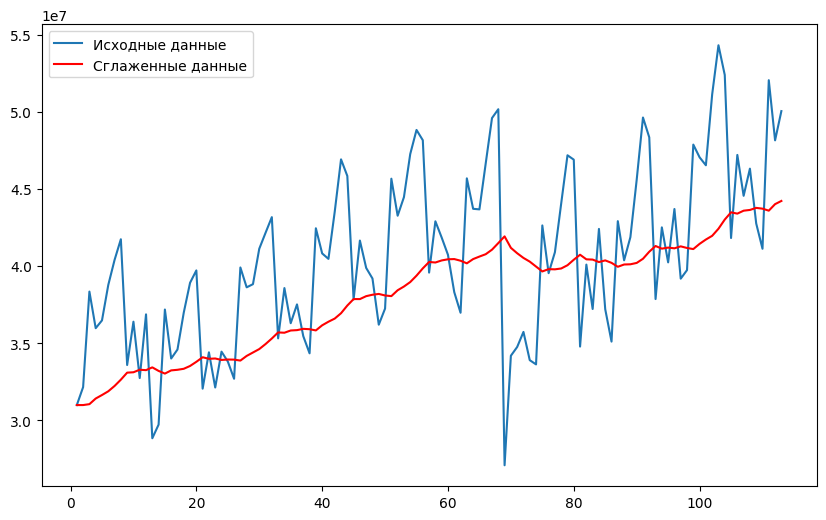

In [17]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

data = pd.read_csv('airmiles.csv', index_col = 0)
model = SimpleExpSmoothing(data)
fit = model.fit(smoothing_level=0.05, optimized=True)
fitted_values = fit.fittedvalues

plt.figure(figsize=(10, 6))
plt.plot(data, label='Исходные данные')
plt.plot(fitted_values, label='Сглаженные данные', color='red')
plt.legend()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


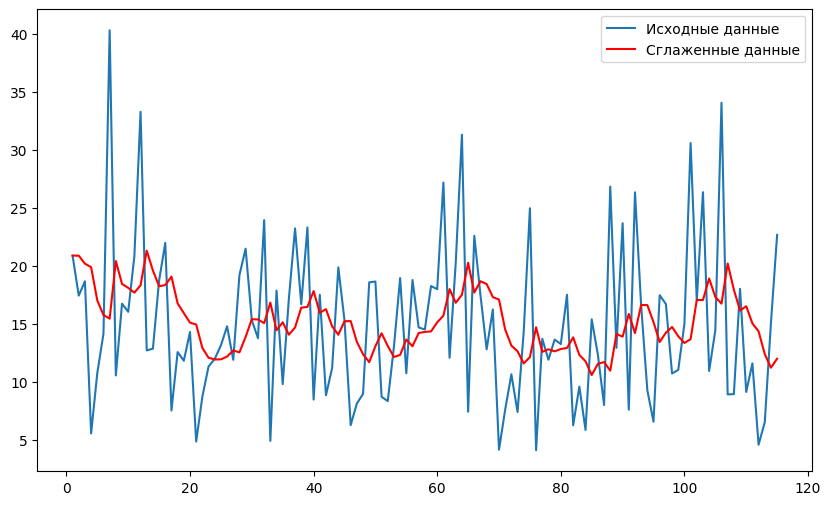

In [18]:
data = pd.read_csv('larain.csv',index_col = 0)
model = SimpleExpSmoothing(data)
fit = model.fit(smoothing_level=0.2, optimized=False)
fitted_values = fit.fittedvalues

plt.figure(figsize=(10, 6))
plt.plot(data, label='Исходные данные')
plt.plot(fitted_values, label='Сглаженные данные', color='red')
plt.legend()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


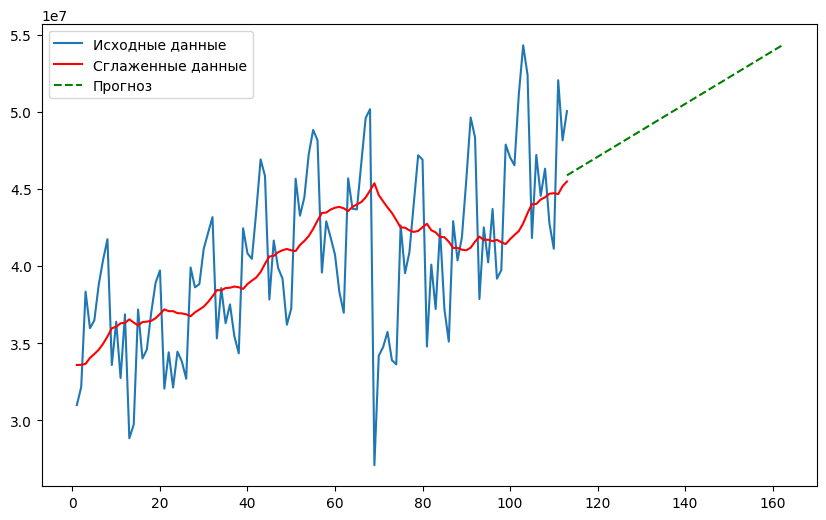

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_trend = pd.read_csv('airmiles.csv', index_col = 0)

model_holt = ExponentialSmoothing(data_trend, trend='add')
fit_holt = model_holt.fit(smoothing_level=0.05, smoothing_trend=0.07, optimized = True)

forecast = fit_holt.forecast(50)

plt.figure(figsize=(10, 6))
plt.plot(data_trend, label='Исходные данные')
plt.plot(fit_holt.fittedvalues, label='Сглаженные данные', color='red')
plt.plot(np.arange(len(data_trend), len(data_trend)+50), forecast, label='Прогноз', linestyle='--', color='green')
plt.legend()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


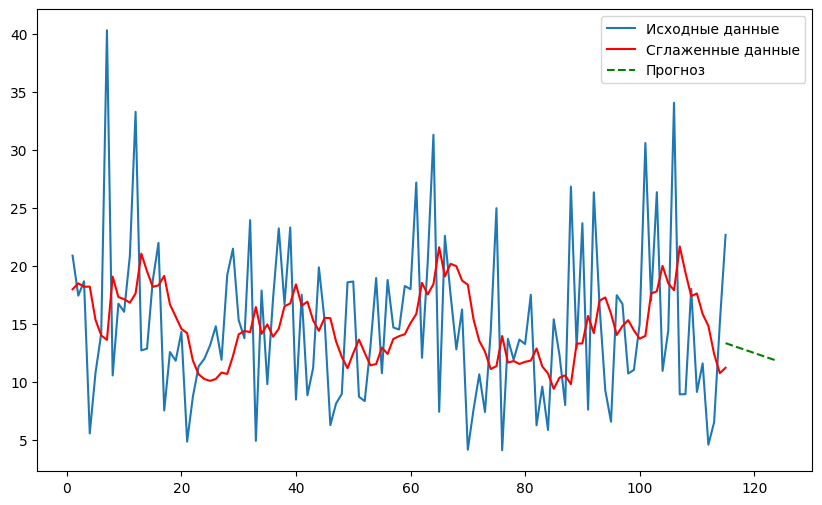

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

data_trend = pd.read_csv('larain.csv', index_col = 0)

model_holt = ExponentialSmoothing(data_trend, trend='add')
fit_holt = model_holt.fit(smoothing_level=0.2, smoothing_trend=0.1, optimized = True)

forecast = fit_holt.forecast(10)

plt.figure(figsize=(10, 6))
plt.plot(data_trend, label='Исходные данные')
plt.plot(fit_holt.fittedvalues, label='Сглаженные данные', color='red')
plt.plot(np.arange(len(data_trend), len(data_trend)+10), forecast, label='Прогноз', linestyle='--', color='green')
plt.legend()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, callin

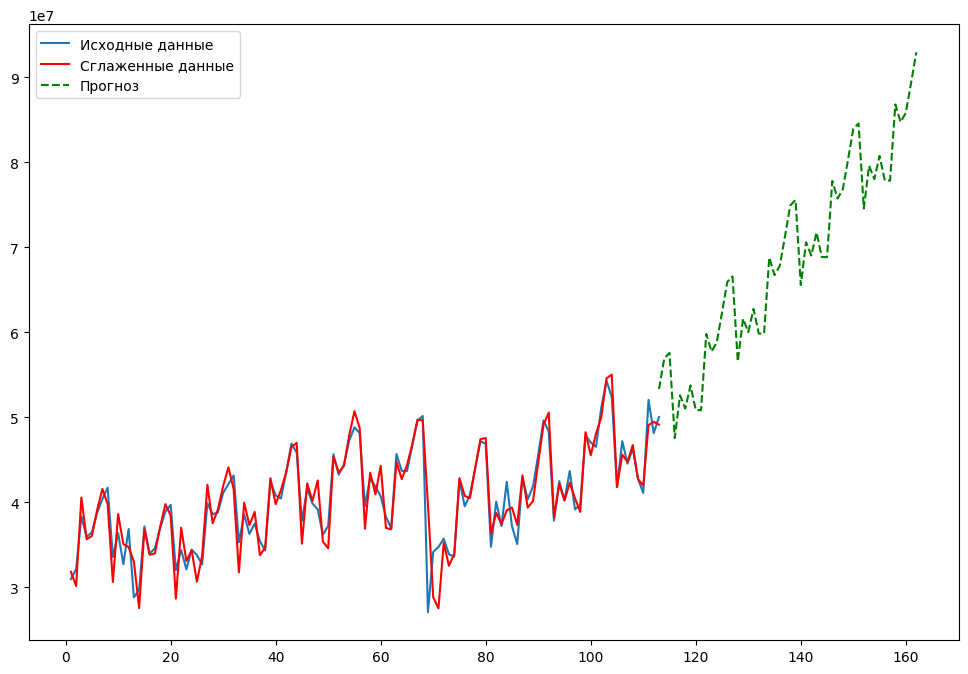

In [22]:
data_seasonal = pd.read_csv('airmiles.csv', index_col = 0)

model_hw = ExponentialSmoothing(data_seasonal, trend='add', seasonal='add', seasonal_periods = 12)

fit_hw = model_hw.fit(smoothing_level=0.75, smoothing_trend=0.61, smoothing_seasonal=0.01, optimized = True)

forecast_hw = fit_hw.forecast(50)

# Визуализация
plt.figure(figsize=(12, 8))
plt.plot(data_seasonal, label='Исходные данные')
plt.plot(fit_hw.fittedvalues, label='Сглаженные данные', color='red')
plt.plot(np.arange(len(data_seasonal), len(data_seasonal)+50), forecast_hw, label='Прогноз', linestyle='--', color='green')
plt.legend()
plt.show()


# Стационарность

Важной характеристикой временного ряда является свойство стационарности

**Определение 1.** Cтрогая стационарность.

Случайный процесс c дискретным временем $x_t:t =0,\pm1,\pm2,...$ называется строго стационарным, если для любого целого $k>0$ для любых моментов времени $t_1,....,t_k$ для любого действительного $s$ распределение процесса в моменты времени $t_1,....,t_k$ и $t_1+s,....,t_k+s$ остается неизменным. Формально запишем это как

$f(x_{t_1},....,x_{t_k}) = f(x_{t_1+s},....,x_{t_k+s})$

Для $k=1$ из строгой стационарности процесса $x_t$ следует, что

$E[x_t]=\mu=const,t=0,\pm1,\pm2,...$

Дисперсия также постоянна во времени

$D[x_t]=E(x_t-\mu_t)^2= \sigma^2=const ,t=0,\pm1,\pm2,...$

При $k=2$ из строгой стационарности процесса $x_t$ следует, что автоковариационная функция и автокорреляционная функция для любых $t\le s$ зависят только от сдвига $|s-t|$

$c(x_t,x_s)=c_{|s-t|}$

$\gamma(x_t,x_s)=\gamma_{|s-t|}$

**Определение 2.** Стационарность в широком смысле.

Случайный процесс c дискретным временем $x_t:t =0,\pm1,\pm2,...$ называется стационарным в широком смысле , если математическое ожидание и дисперсия процесса постоянны 
во времени 

$E[x_t]=\mu=const,t=0,\pm1,\pm2,...$

$D[x_t]=E(x_t-\mu_t)^2= \sigma^2=const ,t=0,\pm1,\pm2,...$

Рассмотренные выше примеры процессов белого шума и скользящего среднего для белого шума это примеры строго стационарных процессов

## Критерии стационарности. Тест Дики-Фуллера

**Тест Дики — Фуллера** — это методика, которая используется при анализе временных рядов для проверки на стационарность. Является одним из тестов на единичные корни (Unit root test). Причем здесь единичные корни выяснится позднее через несколько лекций (см.лекцию Теория коинтеграции). Пока без особых комментариев просто дадим такое определение.

**Определение** Временной ряд $y_t$ имеет единичный корень, или порядок интеграции один, если его первые разности $\Delta y_t = y_t-y_{t-1}$ образуют стационарный ряд.

Тест предложен в 1979 году Дэвидом Дики (англ.) и Уэйном Фуллером (англ.).

В нем проверяется гипотеза о том,что значение коэффициента $\alpha$ в уравнении первого порядка для временного ряда $y_t$ при шуме $\epsilon_t$ $$y_t=\alpha y_{t-1}+\epsilon_t$$ равно единице.

Если гипотеза не отвергается, то говорят , что временной ряд $y_t$ имеет единичный корень, и следовательно он не является стационарным.

Посмотрим как работает тест на некоторых примерах временных рядов из этой лекции.



### Тест Дики-Фуллера для ряда белого шума

Напомним, что в этом случае временной ряд есть просто $y_t=\epsilon_t$ и выглядит на графике так

In [23]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = sm.tsa.stattools.adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = sm.tsa.stattools.kpss(timeseries, nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

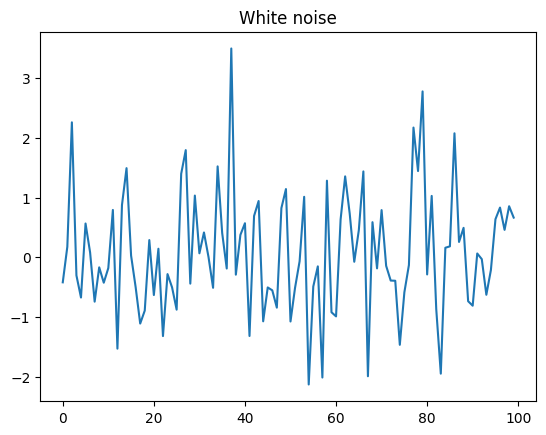

In [24]:
sigma = 1
white_noise  = np.random.normal(0,sigma, size = 100)
plt.plot(white_noise)
plt.title('White noise')
plt.show()

In [25]:
eps  = np.random.normal(0,sigma, size = 100)
x= [eps[0]]
for i in range(len(eps)):
    x.append(x[len(x)-1] + eps[i])
x = np.array(x)
adf_test(x)

Results of Dickey-Fuller Test:
Test Statistic                  -1.856348
p-value                          0.352866
#Lags Used                       0.000000
Number of Observations Used    100.000000
Critical Value (1%)             -3.497501
Critical Value (5%)             -2.890906
Critical Value (10%)            -2.582435
dtype: float64


In [26]:
adf_test(white_noise)

Results of Dickey-Fuller Test:
Test Statistic                -5.673476e+00
p-value                        8.812911e-07
#Lags Used                     3.000000e+00
Number of Observations Used    9.600000e+01
Critical Value (1%)           -3.500379e+00
Critical Value (5%)           -2.892152e+00
Critical Value (10%)          -2.583100e+00
dtype: float64


In [27]:
kpss_test(white_noise)

Results of KPSS Test:
Test Statistic           0.074303
p-value                  0.100000
Lags Used                0.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


/var/folders/j5/bxln7n_n1lqddqxgf6pc4vpc0000gn/T/ipykernel_2320/612326001.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = sm.tsa.stattools.kpss(timeseries, nlags="auto")
